In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.optimize import curve_fit

from cochleasim.models.auditory_filterbank import (
    erb_hz,
    GammatoneFilter,
    apply_gammatone_filter,
    gammatone_frequency_response,
    gammatone_impulse_response,
)

In [8]:
# Test channel: Holdsworth et al. (1988), Section 3 worked example.
# f0=1000 Hz, order 4 -> ERB=128.14 Hz, b=130.57 Hz, 3dB BW=113.59 Hz
# (their reported values use a table constant rounded to 3 decimals;
# our closed-form a_n is exact, see comparison below).
fs = 20000.0
gt = GammatoneFilter(center_frequency_hz=1000.0, order=4)

print(f"f0            = {gt.center_frequency_hz:.2f} Hz")
print(f"ERB(f0)       = {erb_hz(gt.center_frequency_hz):.2f} Hz  (Holdsworth: 128.14)")
print(f"b             = {gt.bandwidth_hz:.4f} Hz  (Holdsworth: 130.57, rounded a_n^-1)")
print(f"3dB bandwidth = {gt.bandwidth_3db_hz:.4f} Hz  (Holdsworth: 113.59, rounded a_n^-1)")
print(f"f0/b          = {gt.center_frequency_hz/gt.bandwidth_hz:.3f}  (valid auditory range: 4-8)")

f0            = 1000.00 Hz
ERB(f0)       = 128.14 Hz  (Holdsworth: 128.14)
b             = 130.5223 Hz  (Holdsworth: 130.57, rounded a_n^-1)
3dB bandwidth = 113.5491 Hz  (Holdsworth: 113.59, rounded a_n^-1)
f0/b          = 7.662  (valid auditory range: 4-8)


In [9]:
# Digital cascade impulse response, and its FFT-derived frequency response
n_samples = 8192
impulse = np.zeros(n_samples)
impulse[0] = 1.0
y = apply_gammatone_filter(impulse, gt, fs)

n_fft = 2**20  # heavy zero-padding for fine frequency resolution
Y = np.fft.rfft(y, n=n_fft)
freqs = np.fft.rfftfreq(n_fft, d=1 / fs)
Y_mag = np.abs(Y)
Y_mag_norm = Y_mag / Y_mag.max()

# Analytic narrow-band approximation (Holdsworth eq. 3), the one actually
# realized by the cascade-of-recursive-filters digital implementation
H_analytic = gammatone_frequency_response(
    freqs, gt.center_frequency_hz, gt.bandwidth_hz, gt.order, exact=False
)
H_mag_norm = np.abs(H_analytic) / np.abs(H_analytic).max()

(-30.0, 2.0)

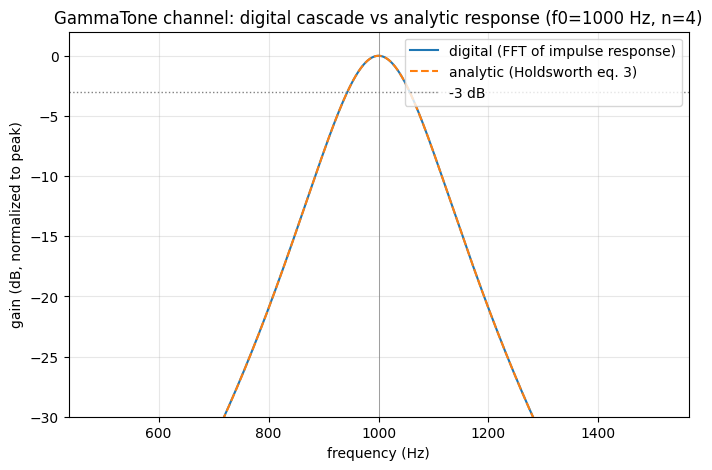

In [10]:
# Plot: digital (FFT) vs analytic frequency response, +-4 ERB around f0
erb = erb_hz(gt.center_frequency_hz)
window = (freqs > gt.center_frequency_hz - 4 * erb) & (freqs < gt.center_frequency_hz + 4 * erb)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs[window], 20 * np.log10(Y_mag_norm[window] + 1e-12), label="digital (FFT of impulse response)")
ax.plot(freqs[window], 20 * np.log10(H_mag_norm[window] + 1e-12), "--", label="analytic (Holdsworth eq. 3)")
ax.axhline(-3, color="gray", linestyle=":", linewidth=1, label="-3 dB")
ax.axvline(gt.center_frequency_hz, color="gray", linewidth=0.5)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("gain (dB, normalized to peak)")
ax.set_title("GammaTone channel: digital cascade vs analytic response (f0=1000 Hz, n=4)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-30, 2)

In [11]:
# Quantitative checks: peak frequency, -3dB bandwidth, RMSE(dB) vs analytic shape
peak_idx = np.argmax(Y_mag)
peak_freq = freqs[peak_idx]

mask = freqs > 0
above_half_power = Y_mag[mask] >= Y_mag.max() / np.sqrt(2)
f_in_band = freqs[mask][above_half_power]
bw_measured = f_in_band.max() - f_in_band.min()

digital_db = 20 * np.log10(Y_mag_norm[window] + 1e-12)
analytic_db = 20 * np.log10(H_mag_norm[window] + 1e-12)
rmse_db = np.sqrt(np.mean((digital_db - analytic_db) ** 2))

print(f"peak frequency        : {peak_freq:.4f} Hz   (nominal f0 = {gt.center_frequency_hz:.1f} Hz)")
print(f"3dB bandwidth measured: {bw_measured:.4f} Hz   (theoretical c4*b = {gt.bandwidth_3db_hz:.4f} Hz, "
      f"err = {100*(bw_measured-gt.bandwidth_3db_hz)/gt.bandwidth_3db_hz:.3f}%)")
print(f"RMSE (dB) vs analytic, +-4 ERB window: {rmse_db:.5f} dB")

peak frequency        : 1000.0038 Hz   (nominal f0 = 1000.0 Hz)
3dB bandwidth measured: 113.5254 Hz   (theoretical c4*b = 113.5491 Hz, err = -0.021%)
RMSE (dB) vs analytic, +-4 ERB window: 0.04181 dB


In [12]:
# Impulse response shape: does the envelope actually match the gamma
# distribution t^(n-1) exp(-2*pi*b*t)? Holdsworth Sec. 5 notes the digital
# cascade has an implicit group delay of dt/2 per recursive stage
# (n stages -> n*dt/2 total), which must be corrected before comparing
# to the t=0-referenced analytic impulse response.
dt = 1.0 / fs
t = np.arange(n_samples) * dt
envelope = np.abs(hilbert(y))

group_delay = gt.order * dt / 2
t_corrected = t - group_delay
valid = t_corrected >= 0

def gamma_envelope(tt, A, n, b):
    return A * np.maximum(tt, 1e-12) ** (n - 1) * np.exp(-2 * np.pi * b * tt)

# Closed-form initial guess for A: the shape function t^(n-1)*exp(-2*pi*b*t)
# peaks at ((n-1)/(2*pi*b*e))^(n-1), not at 1, so A must be scaled to match
# that peak to the measured envelope peak (naively using envelope.max() as
# A misestimates it by several orders of magnitude and stalls the optimizer).
n0, b0 = gt.order, gt.bandwidth_hz
shape_peak = ((n0 - 1) / (2 * np.pi * b0)) ** (n0 - 1) * np.exp(-(n0 - 1)) if n0 > 1 else 1.0
p0 = [envelope.max() / shape_peak, n0, b0]
popt, _ = curve_fit(
    gamma_envelope, t_corrected[valid], envelope[valid], p0=p0, maxfev=20000,
    bounds=([0, 0.5, 1.0], [np.inf, 20.0, 5000.0]),
)
A_hat, n_hat, b_hat = popt

pred = gamma_envelope(t_corrected[valid], *popt)
ss_res = np.sum((envelope[valid] - pred) ** 2)
ss_tot = np.sum((envelope[valid] - envelope[valid].mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"group delay correction (n*dt/2): {group_delay*1000:.4f} ms")
print(f"n_hat = {n_hat:.4f}   (nominal {gt.order})")
print(f"b_hat = {b_hat:.4f} Hz  (nominal {gt.bandwidth_hz:.4f} Hz, "
      f"err = {100*(b_hat-gt.bandwidth_hz)/gt.bandwidth_hz:.3f}%)")
print(f"R^2 (envelope fit) = {r2:.7f}")

group delay correction (n*dt/2): 0.1000 ms
n_hat = 4.0017   (nominal 4)
b_hat = 130.5699 Hz  (nominal 130.5223 Hz, err = 0.036%)
R^2 (envelope fit) = 0.9999998


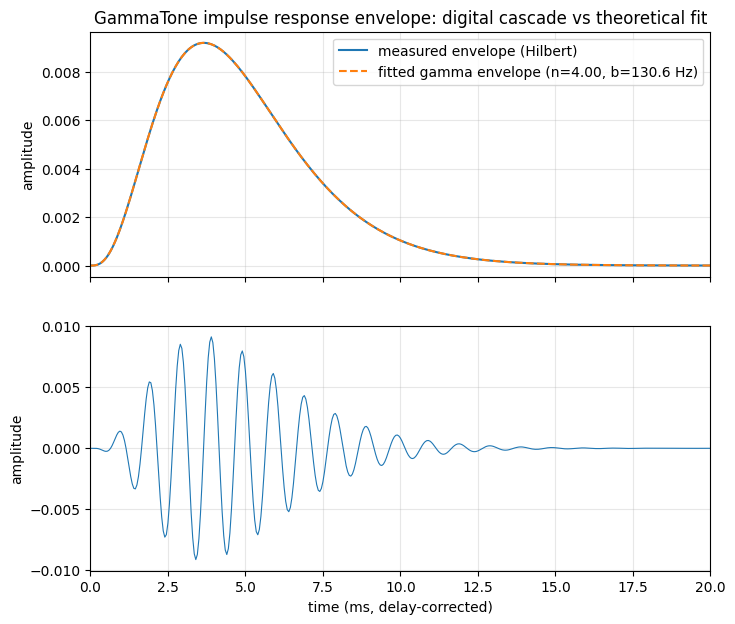

In [13]:
# Plot: measured envelope (Hilbert) vs fitted theoretical gamma envelope,
# and the delay-corrected impulse response itself
fig, (ax_env, ax_wave) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax_env.plot(t_corrected[valid] * 1000, envelope[valid], label="measured envelope (Hilbert)")
ax_env.plot(t_corrected[valid] * 1000, pred, "--", label=f"fitted gamma envelope (n={n_hat:.2f}, b={b_hat:.1f} Hz)")
ax_env.set_ylabel("amplitude")
ax_env.set_title("GammaTone impulse response envelope: digital cascade vs theoretical fit")
ax_env.legend()
ax_env.grid(True, alpha=0.3)

ax_wave.plot(t_corrected[valid] * 1000, y[valid], linewidth=0.8)
ax_wave.set_xlabel("time (ms, delay-corrected)")
ax_wave.set_ylabel("amplitude")
ax_wave.set_xlim(0, 20)
ax_wave.grid(True, alpha=0.3)